In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../results/figures")

contact_feature_table = pd.read_csv(
    PROCESSED_DATA_DIR / "contact_feature_table.csv"
)

contact_feature_table.head()

,file_name,study,group,subject_id,trial,file_path,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference
0,GaCo01_01.txt,Ga,Control,GaCo01,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,94,98,0.775760,0.808771,0.777711,0.784538,0.070878,0.126962,0.091137,0.161831,4,0.006827,0.070694
1,GaCo02_01.txt,Ga,Control,GaCo02,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,102,108,0.841782,0.891299,0.702500,0.715782,0.053232,0.111449,0.075774,0.155703,6,0.013282,0.079928
2,GaCo02_02.txt,Ga,Control,GaCo02,2,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,114,115,0.940815,0.949068,0.680303,0.674213,0.068307,0.089574,0.100407,0.132857,1,0.006090,0.032450
3,GaCo03_01.txt,Ga,Control,GaCo03,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,94,97,0.775760,0.800518,0.857168,0.806341,0.106978,0.120583,0.124804,0.149544,3,0.050827,0.024739
4,GaCo03_02.txt,Ga,Control,GaCo03,2,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,109,108,0.899551,0.891299,0.724902,0.716803,0.080154,0.053564,0.110572,0.074727,1,0.008099,0.035845


In [3]:
contact_feature_table.shape

(306, 20)

In [4]:
contact_feature_table["group"].value_counts()

group
Parkinson    214
Control       92
Name: count, dtype: int64

In [5]:
contact_feature_table["study"].value_counts()

study
Ju    129
Ga    113
Si     64
Name: count, dtype: int64

In [6]:
pd.crosstab(
    contact_feature_table["study"],
    contact_feature_table["group"]
)

group,Control,Parkinson
study,,
Ga,38,75
Ju,25,104
Si,29,35


## Dataset overview

The feature table contains one row per gait recording.  
Each row includes metadata such as study group, health group, subject ID, and trial number, together with basic contact-based gait features.

The dataset contains recordings from three study groups: Ga, Ju, and Si.  
Therefore, group comparisons should be checked both across the full dataset and within each study group.

In [7]:
features_to_analyze = [
    "left_contacts_per_sec",
    "right_contacts_per_sec",
    "mean_left_contact_duration",
    "mean_right_contact_duration",
    "cv_left_contact_duration",
    "cv_right_contact_duration",
    "contact_count_difference",
    "mean_contact_duration_difference",
    "cv_contact_duration_difference"
]

## Selected feature groups

The exploratory analysis focuses on four simple gait concepts:

1. Contact rate: how often each foot contacts the ground per second.
2. Contact duration: how long each foot stays on the ground.
3. Contact duration variability: how consistent or inconsistent the contact periods are.
4. Left-right differences: simple indicators of walking asymmetry.

These features are still preliminary, but they are interpretable and suitable for an early exploratory analysis.

In [8]:
group_summary = contact_feature_table.groupby("group")[features_to_analyze].agg(
    ["mean", "median", "std"]
)

group_summary

left_contacts_per_sec                     right_contacts_per_sec  \
                           mean    median       std                   mean   
group                                                                        
Control                0.903092  0.914830  0.090808               0.904740   
Parkinson              0.902305  0.907349  0.102826               0.904403   

                              mean_left_contact_duration                      \
             median       std                       mean    median       std   
group                                                                          
Control    0.916057  0.095647                   0.702003  0.687836  0.060745   
Parkinson  0.907804  0.106127                   0.736848  0.712676  0.121591   

          mean_right_contact_duration  ... cv_right_contact_duration  \
                                 mean  ...                       std   
group                                  ...                             
Control                      0.700897  ...                  0.056721   
Parkinson                    0.737199  ...                  0.057737   

          contact_count_difference                   \
                              mean median       std   
group                                                 
Control                   1.467391    1.0  1.824444   
Parkinson                 1.827103    1.0  2.519970   

          mean_contact_duration_difference                      \
                                      mean    median       std   
group                                                            
Control                           0.014245  0.008875  0.016318   
Parkinson                         0.024451  0.021305  0.020671   

          cv_contact_duration_difference                      
                                    mean    median       std  
group                                                         
Control                         0.048094  0.034473  0.049697  
Parkinson                       0.054389  0.038509  0.052523  

[2 rows x 27 columns]

In [9]:
clean_group_summary = contact_feature_table.groupby("group")[features_to_analyze].median()
clean_group_summary

,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference
group,,,,,,,,,
Control,0.914830,0.916057,0.687836,0.682939,0.109551,0.118838,1.0,0.008875,0.034473
Parkinson,0.907349,0.907804,0.712676,0.714899,0.128962,0.125734,1.0,0.021305,0.038509


In [10]:
clean_group_summary.to_csv(
    PROCESSED_DATA_DIR / "group_median_feature_summary.csv"
)

In [11]:
def plot_feature_by_group(df, feature, ylabel=None):
    control_values = df[df["group"] == "Control"][feature].dropna()
    parkinson_values = df[df["group"] == "Parkinson"][feature].dropna()
    
    plt.figure(figsize=(8, 5))
    plt.boxplot(
        [control_values, parkinson_values],
        labels=["Control", "Parkinson"]
    )
    plt.ylabel(ylabel if ylabel else feature)
    plt.title(f"{feature} by Group")
    plt.show()

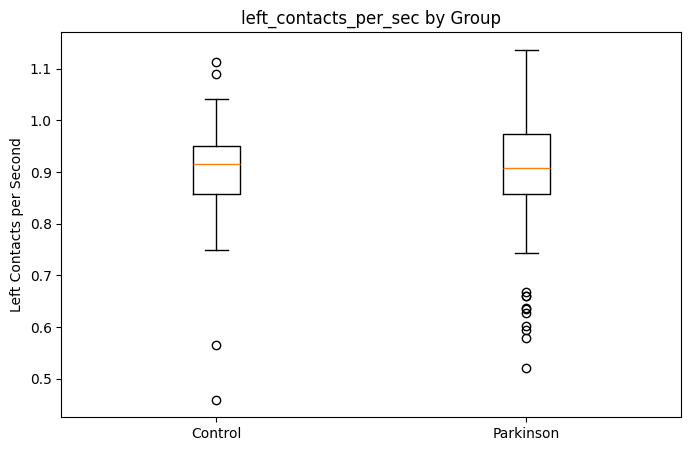

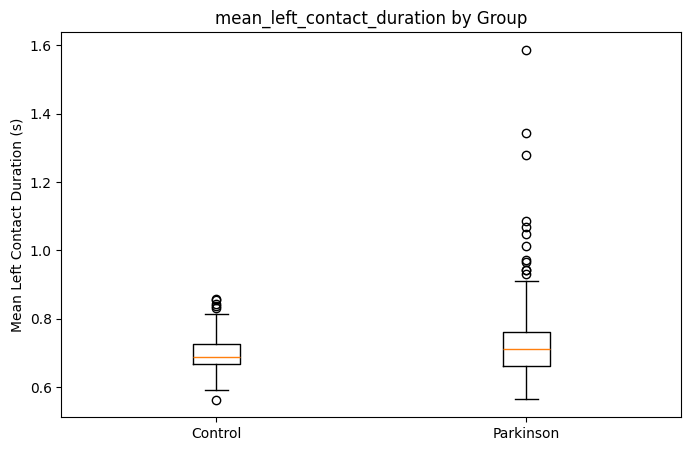

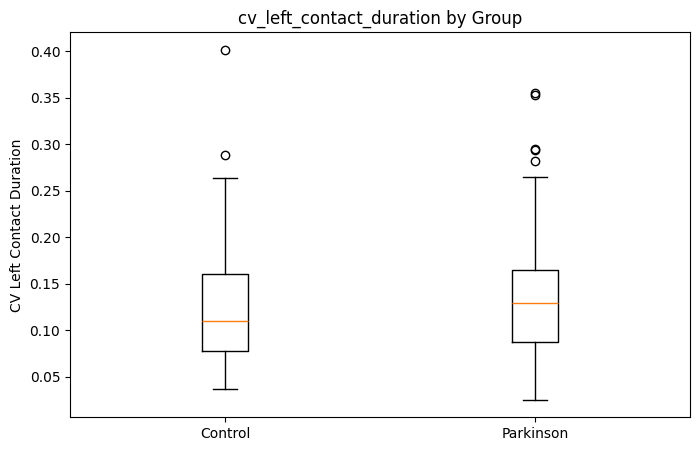

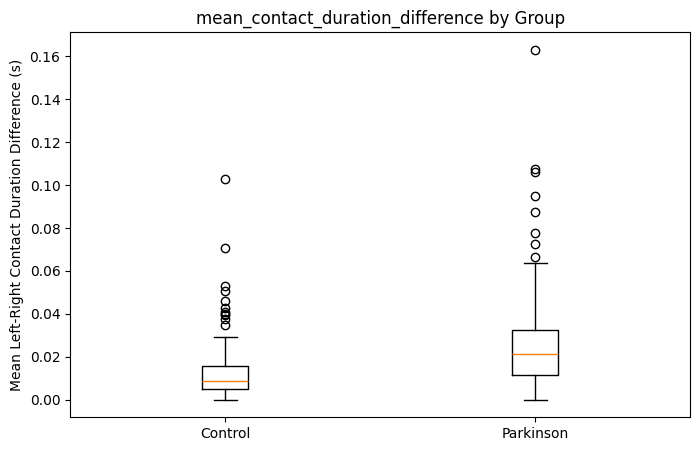

In [12]:
plot_feature_by_group(
    contact_feature_table,
    "left_contacts_per_sec",
    ylabel="Left Contacts per Second"
)

plot_feature_by_group(
    contact_feature_table,
    "mean_left_contact_duration",
    ylabel="Mean Left Contact Duration (s)"
)

plot_feature_by_group(
    contact_feature_table,
    "cv_left_contact_duration",
    ylabel="CV Left Contact Duration"
)

plot_feature_by_group(
    contact_feature_table,
    "mean_contact_duration_difference",
    ylabel="Mean Left-Right Contact Duration Difference (s)"
)

In [13]:
study_group_summary = contact_feature_table.groupby(
    ["study", "group"]
)[features_to_analyze].median()

study_group_summary

left_contacts_per_sec  right_contacts_per_sec  \
study group                                                      
Ga    Control                 0.911931                0.920183   
      Parkinson               0.891299                0.883046   
Ju    Control                 0.910073                0.913873   
      Parkinson               0.934191                0.940641   
Si    Control                 0.940815                0.916057   
      Parkinson               0.874793                0.874793   

                 mean_left_contact_duration  mean_right_contact_duration  \
study group                                                                
Ga    Control                      0.681066                     0.677908   
      Parkinson                    0.741280                     0.750034   
Ju    Control                      0.692581                     0.703249   
      Parkinson                    0.701587                     0.697477   
Si    Control                      0.687611                     0.682383   
      Parkinson                    0.732665                     0.731738   

                 cv_left_contact_duration  cv_right_contact_duration  \
study group                                                            
Ga    Control                    0.114367                   0.124535   
      Parkinson                  0.125965                   0.130401   
Ju    Control                    0.114667                   0.146673   
      Parkinson                  0.139257                   0.144812   
Si    Control                    0.078523                   0.080828   
      Parkinson                  0.097748                   0.090324   

                 contact_count_difference  mean_contact_duration_difference  \
study group                                                                   
Ga    Control                         1.0                          0.008021   
      Parkinson                       1.0                          0.021247   
Ju    Control                         1.0                          0.014882   
      Parkinson                       1.0                          0.020539   
Si    Control                         1.0                          0.006400   
      Parkinson                       1.0                          0.022921   

                 cv_contact_duration_difference  
study group                                      
Ga    Control                          0.028240  
      Parkinson                        0.034074  
Ju    Control                          0.057243  
      Parkinson                        0.048263  
Si    Control                          0.031528  
      Parkinson                        0.025835

In [14]:
study_group_summary.to_csv(
    PROCESSED_DATA_DIR / "study_group_median_feature_summary.csv"
)

In [15]:
def plot_feature_by_study_and_group(df, feature, ylabel=None):
    studies = sorted(df["study"].unique())
    
    control_data = []
    parkinson_data = []
    labels = []
    
    for study in studies:
        study_df = df[df["study"] == study]
        
        control_data.append(
            study_df[study_df["group"] == "Control"][feature].dropna()
        )
        parkinson_data.append(
            study_df[study_df["group"] == "Parkinson"][feature].dropna()
        )
        labels.extend([f"{study}\nControl", f"{study}\nParkinson"])
    
    plot_data = []
    for c, p in zip(control_data, parkinson_data):
        plot_data.extend([c, p])
    
    plt.figure(figsize=(12, 5))
    plt.boxplot(plot_data, labels=labels)
    plt.ylabel(ylabel if ylabel else feature)
    plt.title(f"{feature} by Study and Group")
    plt.xticks(rotation=0)
    plt.show()

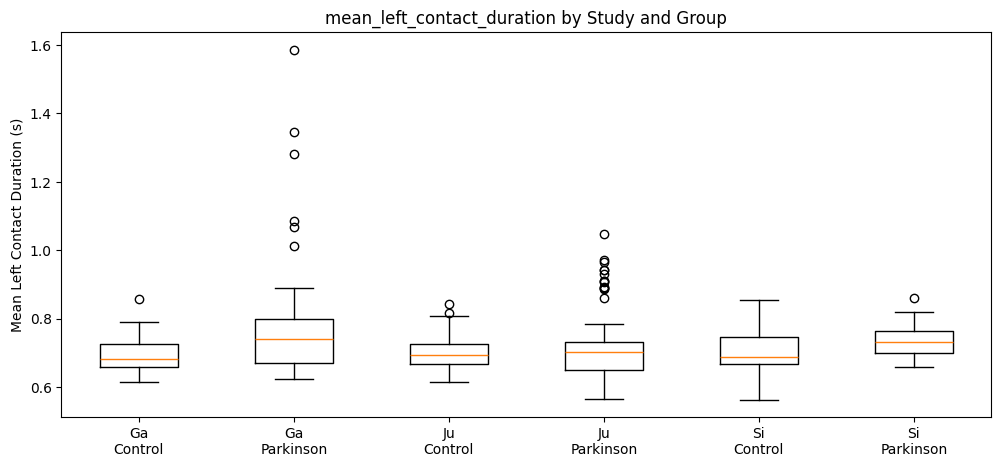

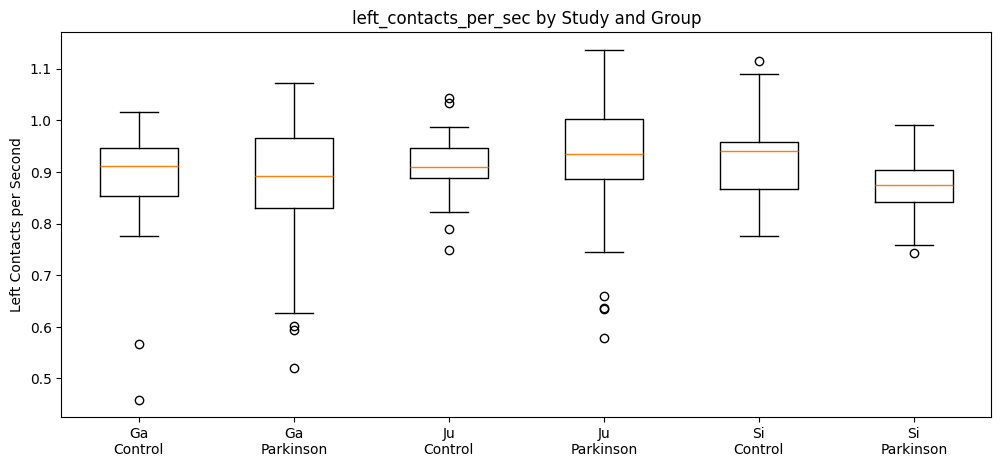

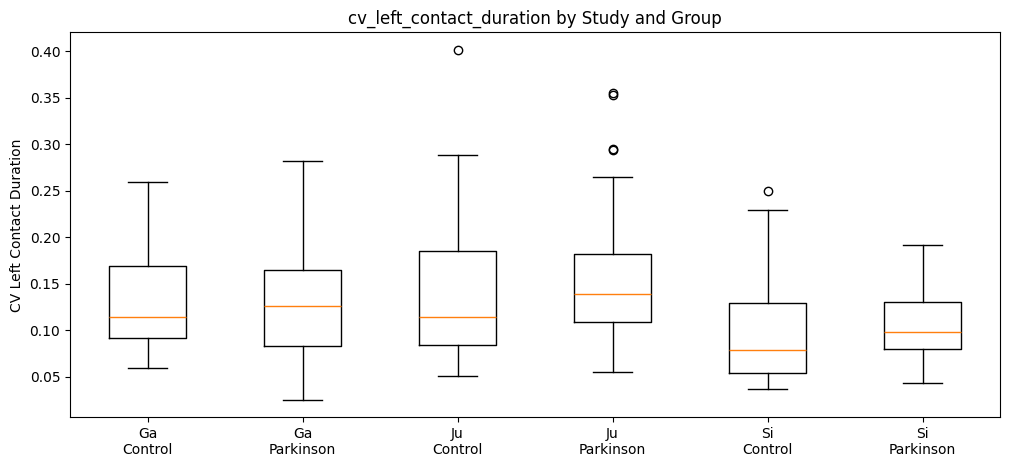

In [16]:
plot_feature_by_study_and_group(
    contact_feature_table,
    "mean_left_contact_duration",
    ylabel="Mean Left Contact Duration (s)"
)

plot_feature_by_study_and_group(
    contact_feature_table,
    "left_contacts_per_sec",
    ylabel="Left Contacts per Second"
)

plot_feature_by_study_and_group(
    contact_feature_table,
    "cv_left_contact_duration",
    ylabel="CV Left Contact Duration"
)

In [17]:
feature_differences = []

for feature in features_to_analyze:
    control_median = contact_feature_table[
        contact_feature_table["group"] == "Control"
    ][feature].median()
    
    parkinson_median = contact_feature_table[
        contact_feature_table["group"] == "Parkinson"
    ][feature].median()
    
    difference = parkinson_median - control_median
    
    feature_differences.append({
        "feature": feature,
        "control_median": control_median,
        "parkinson_median": parkinson_median,
        "difference_parkinson_minus_control": difference,
        "absolute_difference": abs(difference)
    })

feature_difference_table = pd.DataFrame(feature_differences)

feature_difference_table = feature_difference_table.sort_values(
    "absolute_difference",
    ascending=False
)

feature_difference_table

,feature,control_median,parkinson_median,difference_parkinson_minus_control,absolute_difference
3,mean_right_contact_duration,0.682939,0.714899,0.031960,0.031960
2,mean_left_contact_duration,0.687836,0.712676,0.024840,0.024840
4,cv_left_contact_duration,0.109551,0.128962,0.019411,0.019411
7,mean_contact_duration_difference,0.008875,0.021305,0.012431,0.012431
1,right_contacts_per_sec,0.916057,0.907804,-0.008253,0.008253
0,left_contacts_per_sec,0.914830,0.907349,-0.007481,0.007481
5,cv_right_contact_duration,0.118838,0.125734,0.006896,0.006896
8,cv_contact_duration_difference,0.034473,0.038509,0.004036,0.004036
6,contact_count_difference,1.000000,1.000000,0.000000,0.000000


## First exploratory observations

The exploratory plots show that some contact-based features differ between Control and Parkinson recordings, but the pattern is not equally clear for every feature.

Contact rate features appear broadly similar between groups, although some Parkinson recordings show lower contact-rate values. Contact duration and variability features may be more informative, but this needs to be checked across study groups.

Because the dataset includes multiple study groups, a full-dataset comparison alone is not enough. Differences should be interpreted carefully and checked separately within Ga, Ju, and Si recordings.

At this stage, the analysis is descriptive. No final statistical or clinical conclusion is made yet.

In [18]:
def plot_feature_by_group(df, feature, ylabel=None, save=False):
    control_values = df[df["group"] == "Control"][feature].dropna()
    parkinson_values = df[df["group"] == "Parkinson"][feature].dropna()
    
    plt.figure(figsize=(8, 5))
    plt.boxplot(
        [control_values, parkinson_values],
        labels=["Control", "Parkinson"]
    )
    plt.ylabel(ylabel if ylabel else feature)
    plt.title(f"{feature} by Group")
    
    if save:
        output_path = FIGURES_DIR / f"{feature}_by_group.png"
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    
    plt.show()

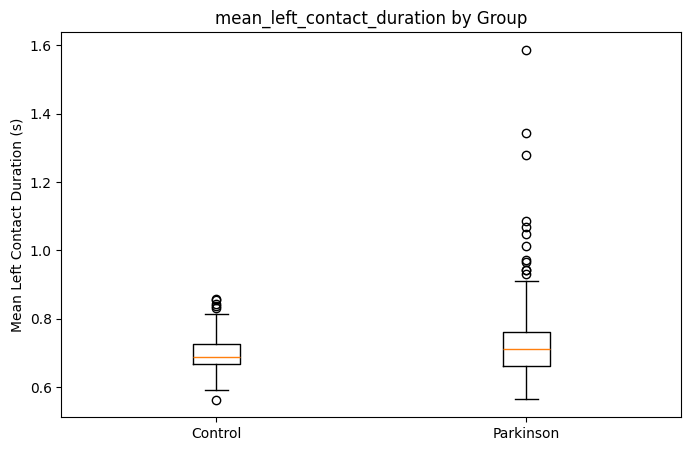

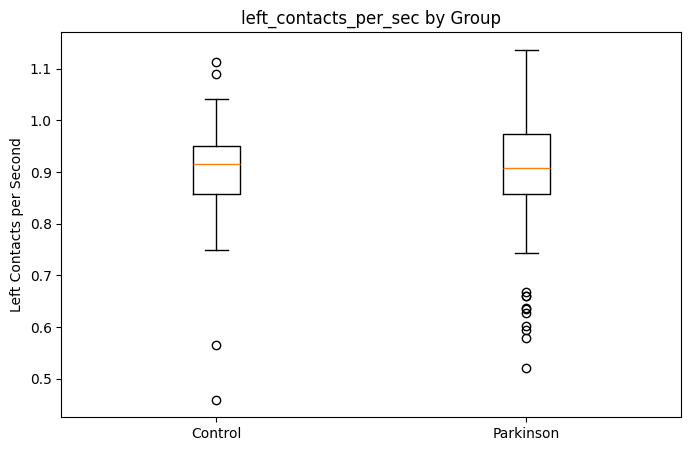

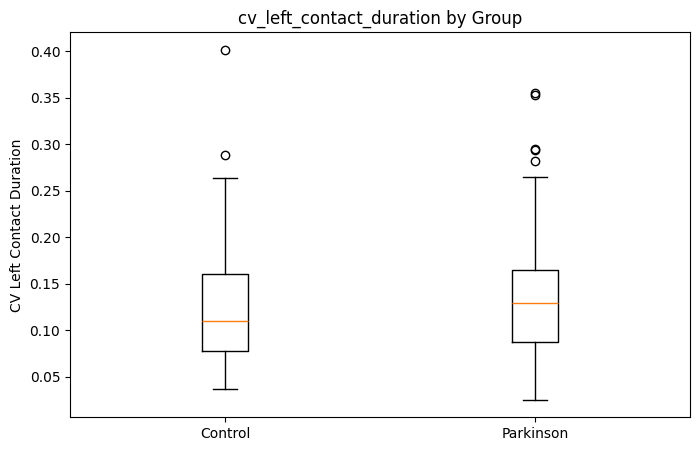

In [19]:
plot_feature_by_group(
    contact_feature_table,
    "mean_left_contact_duration",
    ylabel="Mean Left Contact Duration (s)",
    save=True
)

plot_feature_by_group(
    contact_feature_table,
    "left_contacts_per_sec",
    ylabel="Left Contacts per Second",
    save=True
)

plot_feature_by_group(
    contact_feature_table,
    "cv_left_contact_duration",
    ylabel="CV Left Contact Duration",
    save=True
)

## Milestone 4 conclusion

This notebook performed the first exploratory group-level analysis using the contact-based feature table.

The analysis compared Control and Parkinson recordings across contact rate, contact duration, contact duration variability, and simple left-right difference features. The same features were also inspected within the three study groups: Ga, Ju, and Si.

The results suggest that contact-based gait features can be used for meaningful exploratory analysis, but group-level conclusions should be made carefully. The next milestone should add statistical testing and effect-size analysis to quantify which features show the strongest and most consistent group differences.